# Imports and important variables

In [1]:
import re
import string
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import spacy
from nltk.util import ngrams
from sklearn.manifold import TSNE
from wordcloud import WordCloud
from itertools import chain

nlp = spacy.load("en_core_web_sm")

from module.utils import getData

# plt.style.use("seaborn-v0_8-whitegrid")
# plt.rcParams.update({
#     "font.size": 12,
#     "axes.titlesize": 14,
#     "axes.labelsize": 12
# })

file_path = "data/NLPLabs-2024/Dont_Patronize_Me_Trainingset/dontpatronizeme_pcl.tsv"
split_file_path_val = "data/dontpatronizeme/semeval-2022/practice splits/dev_semeval_parids-labels.csv"
split_file_path_train = "data/dontpatronizeme/semeval-2022/practice splits/train_semeval_parids-labels.csv"

splits = {
    "train": split_file_path_train,
    "val": split_file_path_val
}

train_data = getData(file_path, splits["train"])
val_data = getData(file_path, splits["val"])

In [4]:
PAT_COLOR = "#d62728"
NEU_COLOR = "#1f77b4"
COMMON_COLOR = "#9467bd"
BG_COLOR = "#fafafa"
GRID_COLOR = "#e6e6e6"


def _apply_style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=11, labelpad=8, color="#000000", weight="bold")
    ax.set_ylabel(ylabel, fontsize=11, labelpad=8, color="#000000", weight="bold")
    ax.tick_params(colors="#000000", labelsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#dddddd")
    ax.spines["bottom"].set_color("#dddddd")
    ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.set_facecolor(BG_COLOR)


def basicClean(text):
    text = text.lower()
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"&\w+;", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenizeText(text, remove_stopwords=False):
    doc = nlp(text)
    return [
        t.text for t in doc
        if not t.is_space and not t.is_punct
        and (not remove_stopwords or not t.is_stop)
    ]


def preprocessDataset(dataset):
    cleaned = []
    for d in dataset:
        text = basicClean(d["text"])
        if len(tokenizeText(text, remove_stopwords=True)) >= 3:
            cleaned.append({"text": text, "label": d["label"]})
    print(f"Kept {len(cleaned)} / {len(dataset)} samples after cleaning.")
    return cleaned


def splitByLabel(dataset):
    patronizing = [d["text"] for d in dataset if d["label"] == 1]
    neutral = [d["text"] for d in dataset if d["label"] == 0]
    return patronizing, neutral


class TokenCache:
    def __init__(self, texts, remove_stopwords=False):
        unique = list(dict.fromkeys(texts))
        self._cache = {}
        for text, doc in zip(unique, nlp.pipe(unique, batch_size=256)):
            self._cache[text] = [
                t.text for t in doc
                if not t.is_space and not t.is_punct
                and (not remove_stopwords or not t.is_stop)
            ]

    def get(self, text):
        return self._cache[text]

    def lengths(self, texts):
        return [len(self._cache[t]) for t in texts]


class StatisticalProfiler:
    def __init__(self, dataset, cache):
        self.dataset = dataset
        self.cache = cache
        self.labels = [d["label"] for d in dataset]

    def _classDistribution(self):
        counter = Counter(self.labels)
        total = len(self.labels)
        return {
            "patronizing": counter[1],
            "neutral": counter[0],
            "patronizing_pct": round(counter[1] / total * 100, 2),
            "neutral_pct": round(counter[0] / total * 100, 2),
            "imbalance_ratio": round(counter[0] / counter[1], 2) if counter[1] else None,
        }

    def _plotRaw(self, lengths_by_label):
        fig, ax = plt.subplots(figsize=(9, 4.5))
        fig.patch.set_facecolor(BG_COLOR)

        ax.hist(lengths_by_label[0], bins=35, alpha=0.6,
                color=NEU_COLOR, edgecolor="white", linewidth=0.4,
                label="Neutral")

        ax.hist(lengths_by_label[1], bins=35, alpha=0.6,
                color=PAT_COLOR, edgecolor="white", linewidth=0.4,
                label="Patronizing")

        ax.legend(frameon=False)
        _apply_style(ax, "Token count", "Frequency")
        plt.tight_layout()
        plt.show()

    def _plotNormalised(self, lengths_by_label):
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        fig.patch.set_facecolor(BG_COLOR)

        axes[0].hist(lengths_by_label[0], bins=35, density=True,
                     alpha=0.55, color=NEU_COLOR,
                     edgecolor="white", linewidth=0.4)
        axes[0].set_title("Neutral")
        _apply_style(axes[0], "Token count", "Density")

        axes[1].hist(lengths_by_label[1], bins=35, density=True,
                     alpha=0.65, color=PAT_COLOR,
                     edgecolor="white", linewidth=0.4)
        axes[1].set_title("Patronizing")
        _apply_style(axes[1], "Token count", "Density")

        plt.tight_layout()
        plt.show()

    def run(self):
        texts = [d["text"] for d in self.dataset]
        lengths = self.cache.lengths(texts)
        dist = self._classDistribution()

        print(f"\nTotal samples : {len(self.dataset)}")
        print(f"Avg tokens    : {np.mean(lengths):.1f}")
        print(f"Min / Max     : {np.min(lengths)} / {np.max(lengths)}")
        print(f"Std tokens    : {np.std(lengths):.1f}")
        print(f"Vocab size    : {len({t for toks in self.cache._cache.values() for t in toks})}")
        print(f"\nPatronizing   : {dist['patronizing']} ({dist['patronizing_pct']}%)")
        print(f"Neutral       : {dist['neutral']} ({dist['neutral_pct']}%)")
        print(f"Neutral:Patron: {dist['imbalance_ratio']}:1")

        lengths_by_label = {0: [], 1: []}
        for d, l in zip(self.dataset, lengths):
            lengths_by_label[d["label"]].append(l)

        self._plotRaw(lengths_by_label)
        self._plotNormalised(lengths_by_label)

        return lengths, dist


class LexicalAnalyzer:
    def __init__(self, dataset, cache):
        self.cache = cache
        self.patronizing, self.neutral = splitByLabel(dataset)

    def _getCounts(self, texts, n):
        return Counter(chain.from_iterable(
            ngrams(self.cache.get(t), n) for t in texts
        ))

    def _logOdds(self, pat_counts, neu_counts, alpha=0.01):
        vocab = set(pat_counts) | set(neu_counts)
        total_pat = sum(pat_counts.values())
        total_neu = sum(neu_counts.values())
        V = len(vocab)

        scores = {}
        for g in vocab:
            c1 = pat_counts.get(g, 0)
            c0 = neu_counts.get(g, 0)
            p1 = (c1 + alpha) / (total_pat + alpha * V)
            p0 = (c0 + alpha) / (total_neu + alpha * V)
            scores[g] = np.log(p1 / p0)

        return scores

    def _plotDivergingLogOdds(self, scores, pat_counts, neu_counts, n, label):
        sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top_pat = sorted_scores[:10]
        top_neu = sorted_scores[-10:]

        entries = top_pat + top_neu[::-1]
        phrases = [" ".join(g) for g, _ in entries]
        values = [v for _, v in entries]
        colors = [PAT_COLOR if v > 0 else NEU_COLOR for v in values]

        fig, ax = plt.subplots(figsize=(8, 7))
        fig.patch.set_facecolor(BG_COLOR)

        bars = ax.barh(phrases, values, color=colors, height=0.65)
        ax.axvline(0, color="#000000", linewidth=0.8, linestyle="--")

        ax.set_xlabel("Log-Odds Ratio", fontsize=11, labelpad=8, color="#000000")
        ax.set_title(f"{label} — Log-Odds (Patronizing vs. Neutral)", fontsize=12, pad=10)
        ax.tick_params(colors="#000000", labelsize=10)
        for label in ax.get_yticklabels():
            label.set_fontweight("bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#dddddd")
        ax.spines["bottom"].set_color("#dddddd")
        ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_facecolor(BG_COLOR)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=PAT_COLOR, label="Patronizing"),
            Patch(facecolor=NEU_COLOR, label="Neutral"),
        ]
        ax.legend(handles=legend_elements, frameon=False, fontsize=9)

        plt.tight_layout()
        plt.show()

    def _plotGroupedCommon(self, pat_counts, neu_counts, n, label):
        common_vocab = set(pat_counts) & set(neu_counts)
        common = sorted(
            common_vocab,
            key=lambda g: pat_counts[g] + neu_counts[g],
            reverse=True
        )[:10]

        phrases = [" ".join(g) for g in common]
        pat_vals = [pat_counts[g] for g in common]
        neu_vals = [neu_counts[g] for g in common]

        total_pat = sum(pat_counts.values())
        total_neu = sum(neu_counts.values())
        pat_freq = [v / total_pat * 100 for v in pat_vals]
        neu_freq = [v / total_neu * 100 for v in neu_vals]

        y = np.arange(len(phrases))
        bar_h = 0.35

        fig, ax = plt.subplots(figsize=(9, 6))
        fig.patch.set_facecolor(BG_COLOR)

        ax.barh(y + bar_h / 2, pat_freq, bar_h, color=PAT_COLOR, alpha=0.85, label="Patronizing")
        ax.barh(y - bar_h / 2, neu_freq, bar_h, color=NEU_COLOR, alpha=0.85, label="Neutral")

        ax.set_yticks(y)
        ax.set_yticklabels(phrases, fontsize=10, fontweight="bold")
        ax.set_xlabel("Relative Frequency (%)", fontsize=11, labelpad=8, color="#000000")
        ax.set_title(f"Most Common {label} — Class Frequency Comparison", fontsize=12, pad=10)
        ax.legend(frameon=False, fontsize=9)

        ax.tick_params(colors="#000000", labelsize=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#dddddd")
        ax.spines["bottom"].set_color("#dddddd")
        ax.xaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_facecolor(BG_COLOR)

        plt.tight_layout()
        plt.show()

    def run(self):
        for n, label in [(1, "Unigrams"), (2, "Bigrams"), (3, "Trigrams")]:
            pat_counts = self._getCounts(self.patronizing, n)
            neu_counts = self._getCounts(self.neutral, n)
            scores = self._logOdds(pat_counts, neu_counts)

            self._plotGroupedCommon(pat_counts, neu_counts, n, label)
            self._plotDivergingLogOdds(scores, pat_counts, neu_counts, n, label)


class SemanticAnalyzer:
    def __init__(self, dataset):
        self.patronizing, self.neutral = splitByLabel(dataset)

    def _posDistribution(self, texts, limit=200):
        pos_counts = Counter()
        for doc in nlp.pipe(texts[:limit], batch_size=128):
            for token in doc:
                if not token.is_space:
                    pos_counts[token.pos_] += 1
        total = sum(pos_counts.values())
        return {k: round(v / total * 100, 2) for k, v in pos_counts.most_common(8)}

    def _plotPosComparison(self, pos_pat, pos_neu):
        all_tags = list(dict.fromkeys(list(pos_pat.keys()) + list(pos_neu.keys())))

        pat_vals = [pos_pat.get(tag, 0) for tag in all_tags]
        neu_vals = [pos_neu.get(tag, 0) for tag in all_tags]

        x = np.arange(len(all_tags))
        bar_w = 0.35

        fig, ax = plt.subplots(figsize=(10, 5))
        fig.patch.set_facecolor(BG_COLOR)

        ax.bar(x - bar_w / 2, pat_vals, bar_w, color=PAT_COLOR, alpha=0.85, label="Patronizing")
        ax.bar(x + bar_w / 2, neu_vals, bar_w, color=NEU_COLOR, alpha=0.85, label="Neutral")

        ax.set_xticks(x)
        ax.set_xticklabels(all_tags, fontsize=10)
        ax.set_ylabel("Relative Frequency (%)", fontsize=11, labelpad=8, color="#000000")
        ax.set_xlabel("POS Tag", fontsize=11, labelpad=8, color="#000000")
        ax.set_title("POS Tag Distribution — Patronizing vs. Neutral", fontsize=12, pad=10)
        ax.legend(frameon=False, fontsize=9)

        ax.tick_params(colors="#555555", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#dddddd")
        ax.spines["bottom"].set_color("#dddddd")
        ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_facecolor(BG_COLOR)

        plt.tight_layout()
        plt.show()

    def _plotPosDelta(self, pos_pat, pos_neu):
        all_tags = list(dict.fromkeys(list(pos_pat.keys()) + list(pos_neu.keys())))
        deltas = [pos_pat.get(tag, 0) - pos_neu.get(tag, 0) for tag in all_tags]
        colors = [PAT_COLOR if d > 0 else NEU_COLOR for d in deltas]

        fig, ax = plt.subplots(figsize=(10, 4))
        fig.patch.set_facecolor(BG_COLOR)

        ax.bar(all_tags, deltas, color=colors, alpha=0.85, width=0.5)
        ax.axhline(0, color="#000000", linewidth=0.8, linestyle="--")

        ax.set_ylabel("Δ Frequency (Patronizing − Neutral, %)", fontsize=11, labelpad=8, color="#000000")
        ax.set_xlabel("POS Tag", fontsize=11, labelpad=8, color="#000000")
        ax.set_title("POS Tag Frequency Difference", fontsize=12, pad=10)

        ax.tick_params(colors="#555555", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#dddddd")
        ax.spines["bottom"].set_color("#dddddd")
        ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.set_facecolor(BG_COLOR)

        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor=PAT_COLOR, label="Higher in Patronizing"),
            Patch(facecolor=NEU_COLOR, label="Higher in Neutral"),
        ]
        ax.legend(handles=legend_elements, frameon=False, fontsize=9)

        plt.tight_layout()
        plt.show()

    def run(self):
        pos_pat = self._posDistribution(self.patronizing)
        pos_neu = self._posDistribution(self.neutral)

        for label, dist in [("Patronizing", pos_pat), ("Neutral", pos_neu)]:
            print(f"\nPOS — {label}")
            for k, v in dist.items():
                print(f"{k:8s}: {v}%")

        self._plotPosComparison(pos_pat, pos_neu)
        self._plotPosDelta(pos_pat, pos_neu)

        return pos_pat, pos_neu


class NoiseDetector:
    def __init__(self, dataset):
        self.dataset = dataset

    def run(self, lengths):
        seen = {}
        duplicates = []
        for i, d in enumerate(self.dataset):
            if d["text"] in seen: 
                duplicates.append((seen[d["text"]], i))
            else:
                seen[d["text"]] = i

        print(f"\nDuplicates remaining : {len(duplicates)}")
        print(f"Suggested max_length : {int(np.percentile(lengths, 95))} tokens")


def runFullEda(dataset):
    dataset = preprocessDataset(dataset)

    print("\nFULL-TOKEN ANALYSIS")
    cache_full = TokenCache([d["text"] for d in dataset], remove_stopwords=False)

    lengths, _ = StatisticalProfiler(dataset, cache_full).run()
    LexicalAnalyzer(dataset, cache_full).run()
    SemanticAnalyzer(dataset).run()
    NoiseDetector(dataset).run(lengths)

    print("\nSTOPWORDS-REMOVED ANALYSIS")
    cache_nosw = TokenCache([d["text"] for d in dataset], remove_stopwords=True)
    StatisticalProfiler(dataset, cache_nosw).run()
    LexicalAnalyzer(dataset, cache_nosw).run()

    print("\nDone.")

Kept 8365 / 8375 samples after cleaning.

FULL-TOKEN ANALYSIS

Total samples : 8365
Avg tokens    : 43.9
Min / Max     : 3 / 820
Std tokens    : 26.7
Vocab size    : 27508

Patronizing   : 793 (9.48%)
Neutral       : 7572 (90.52%)
Neutral:Patron: 9.55:1


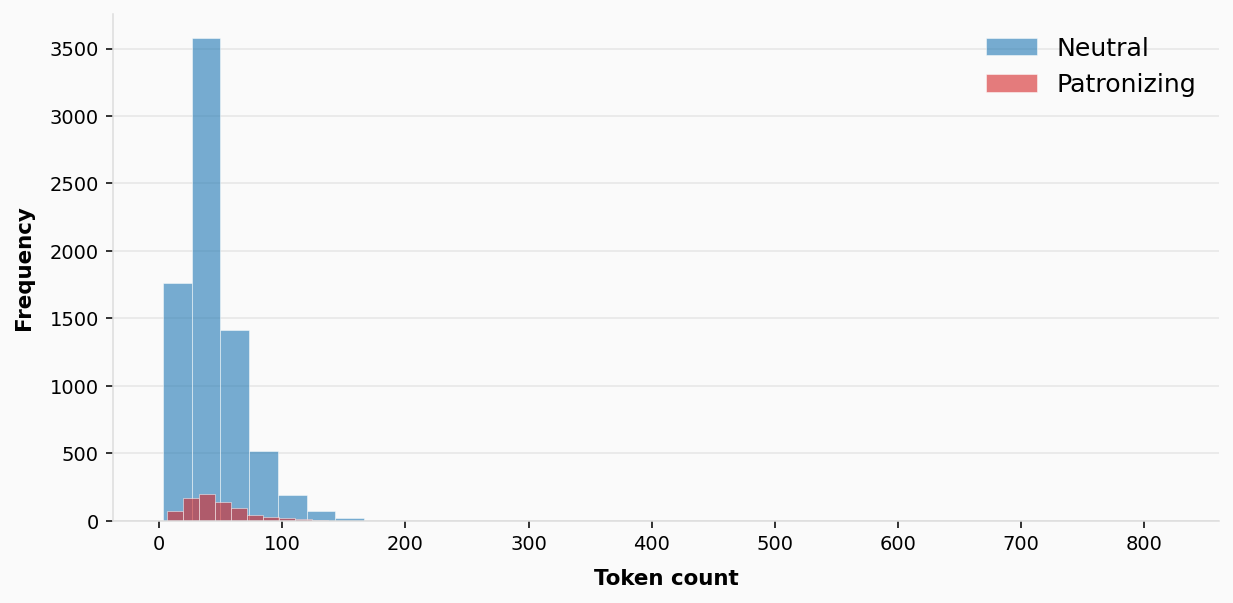

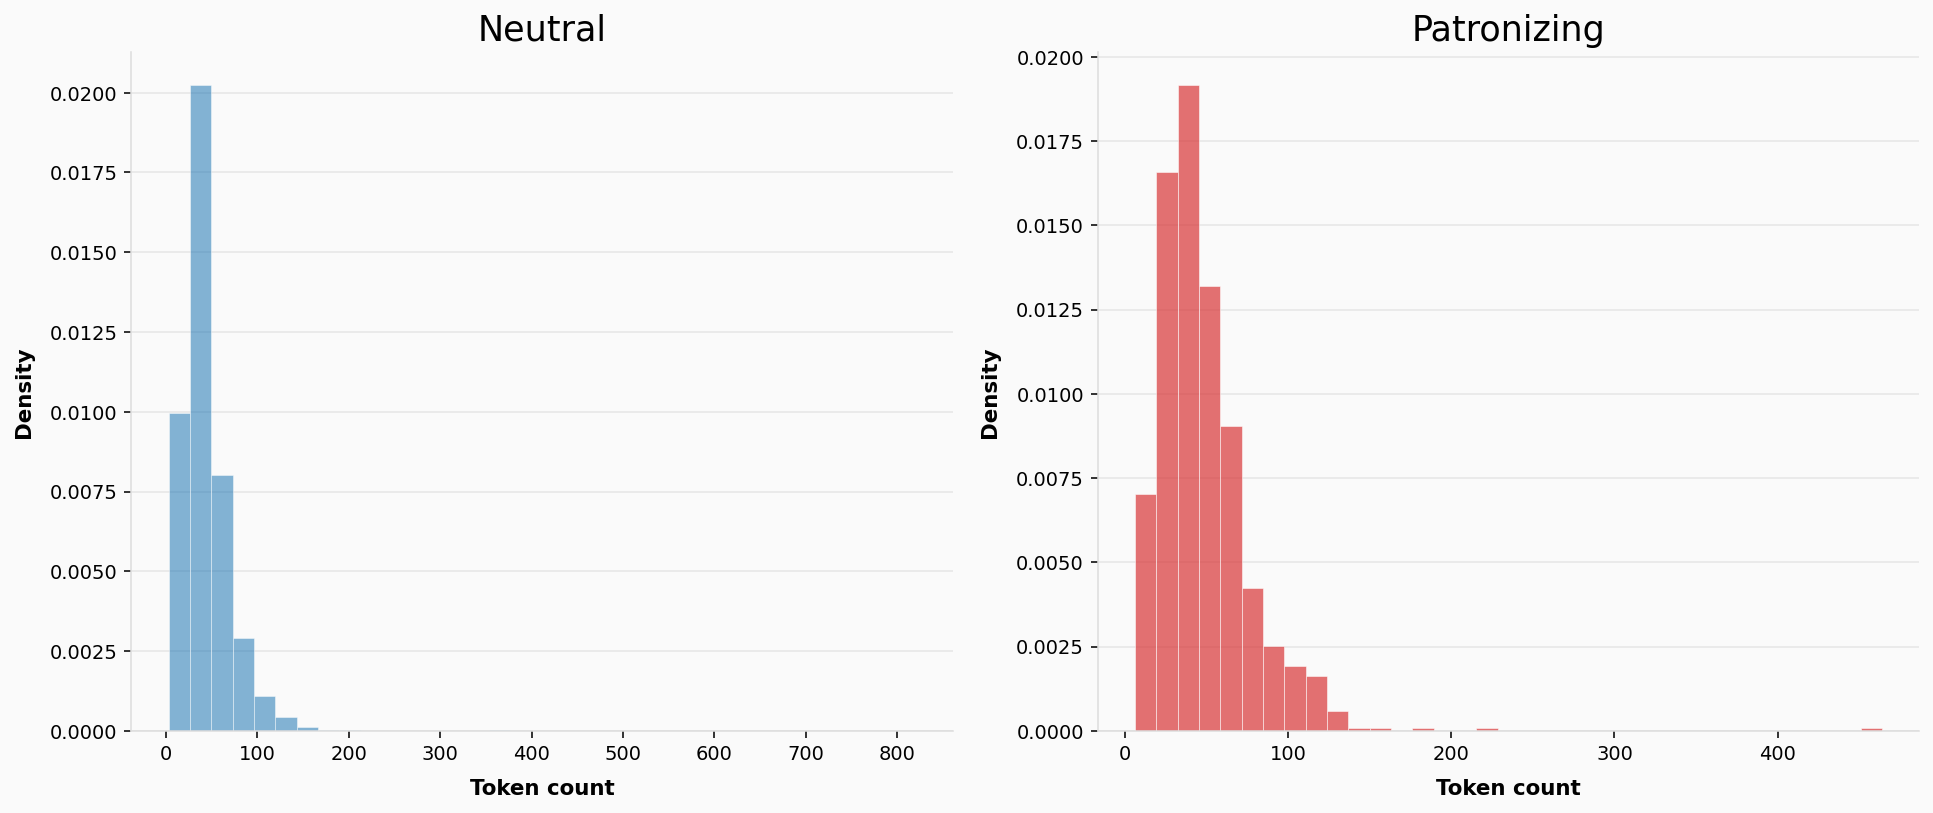

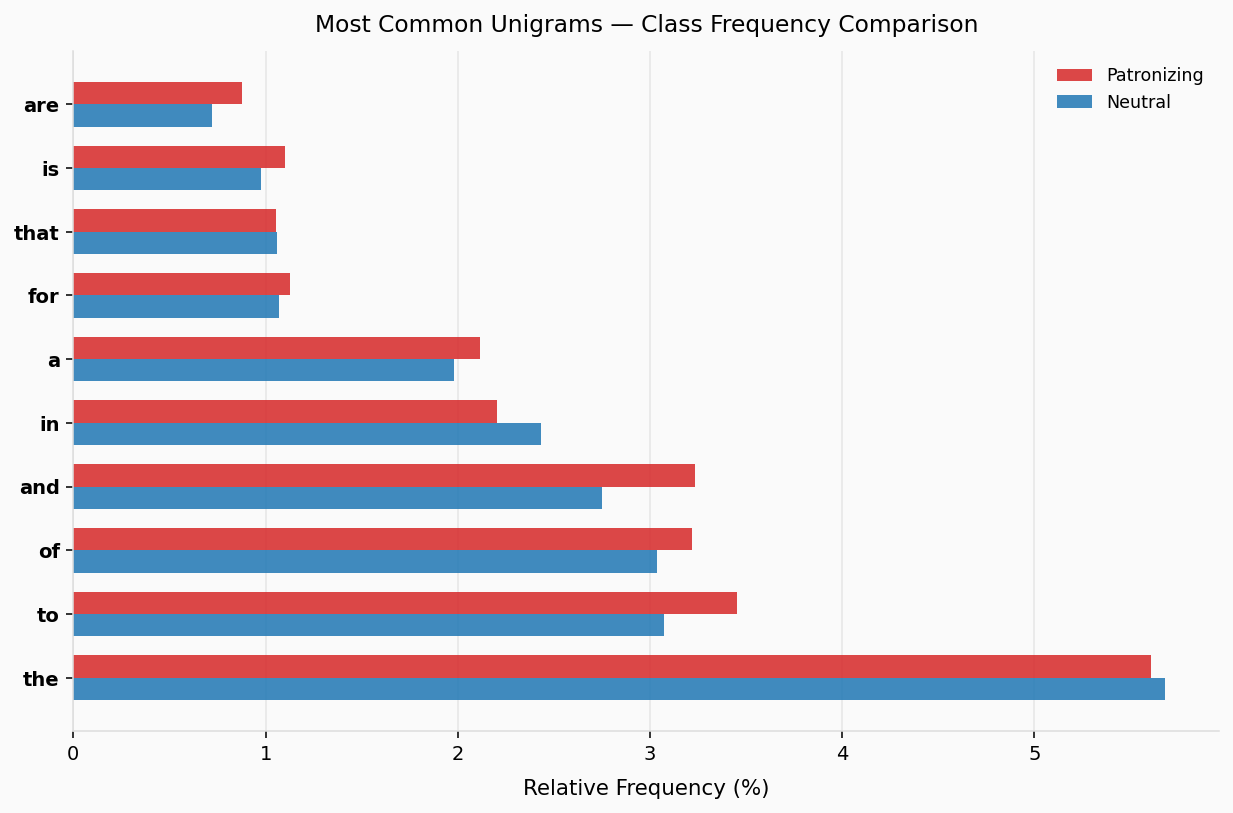

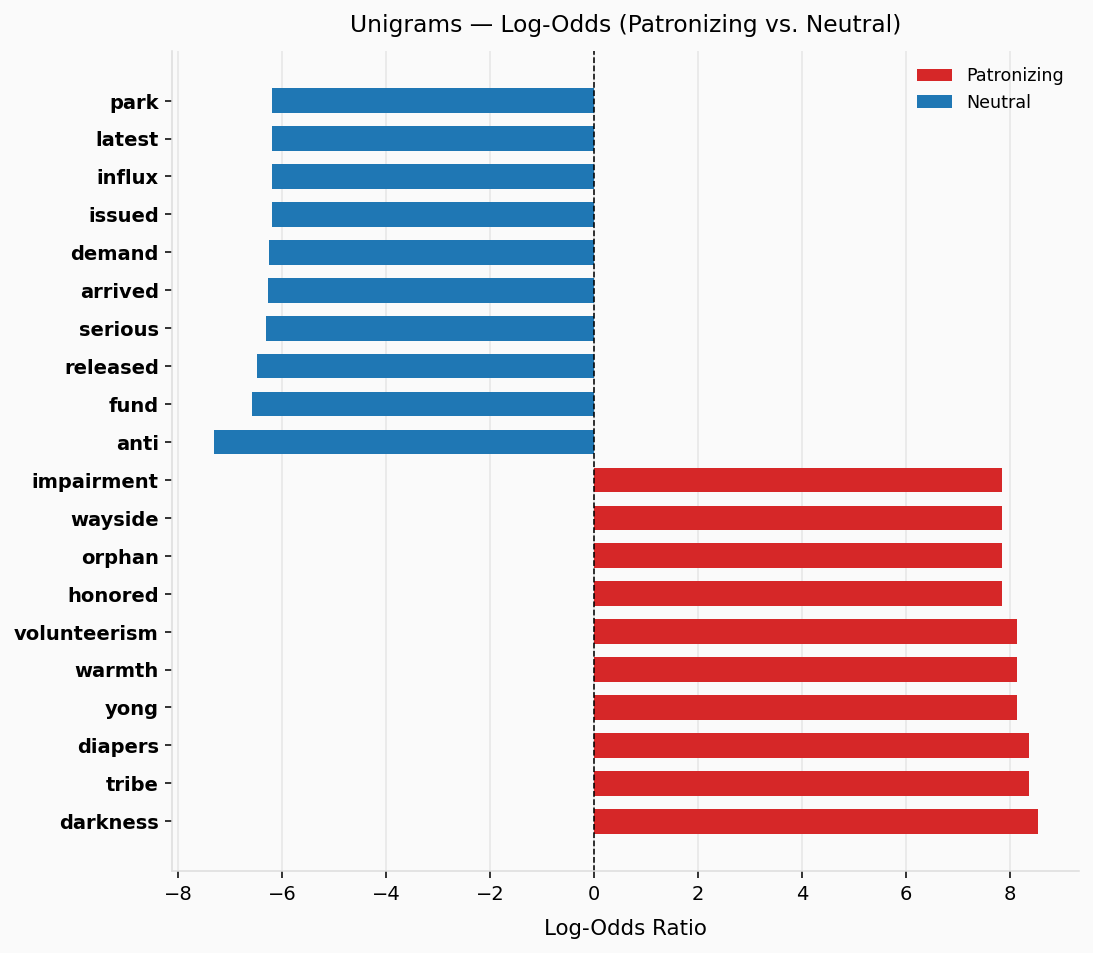

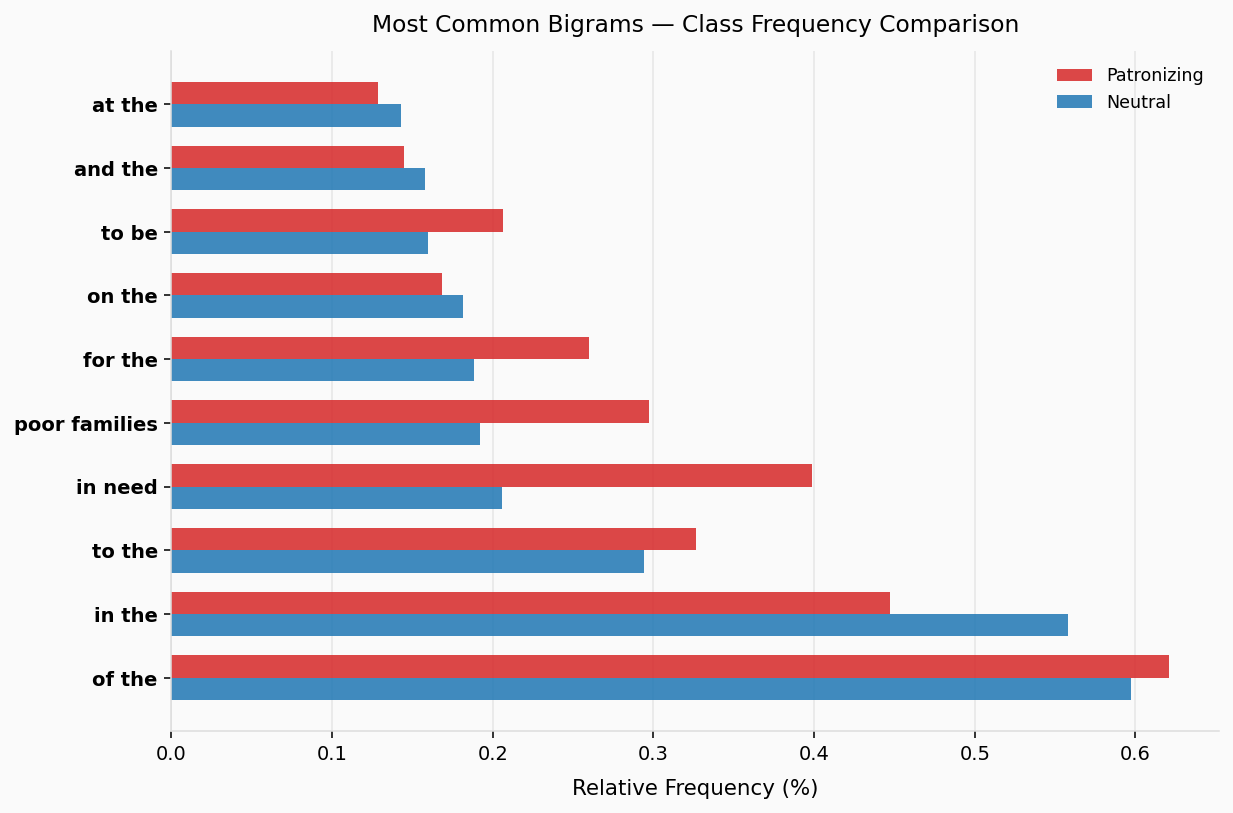

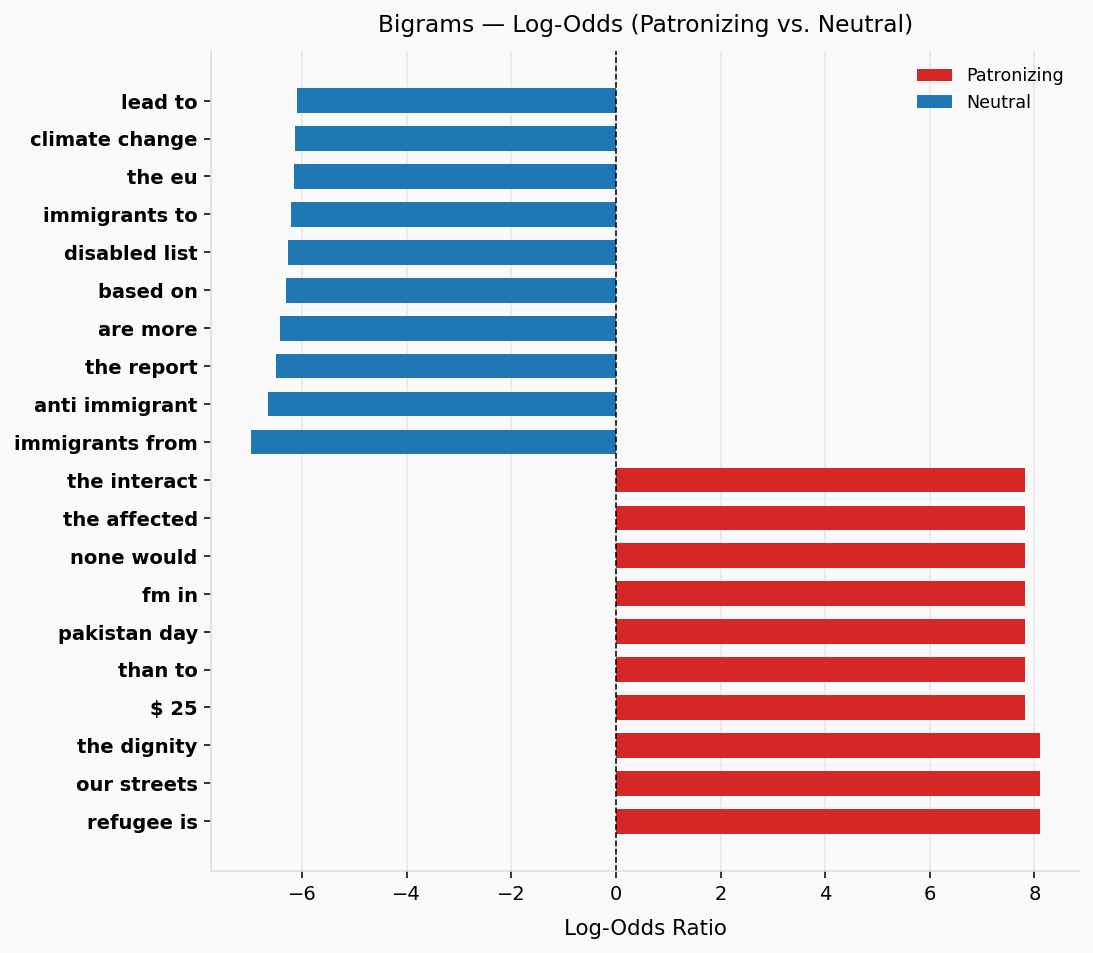

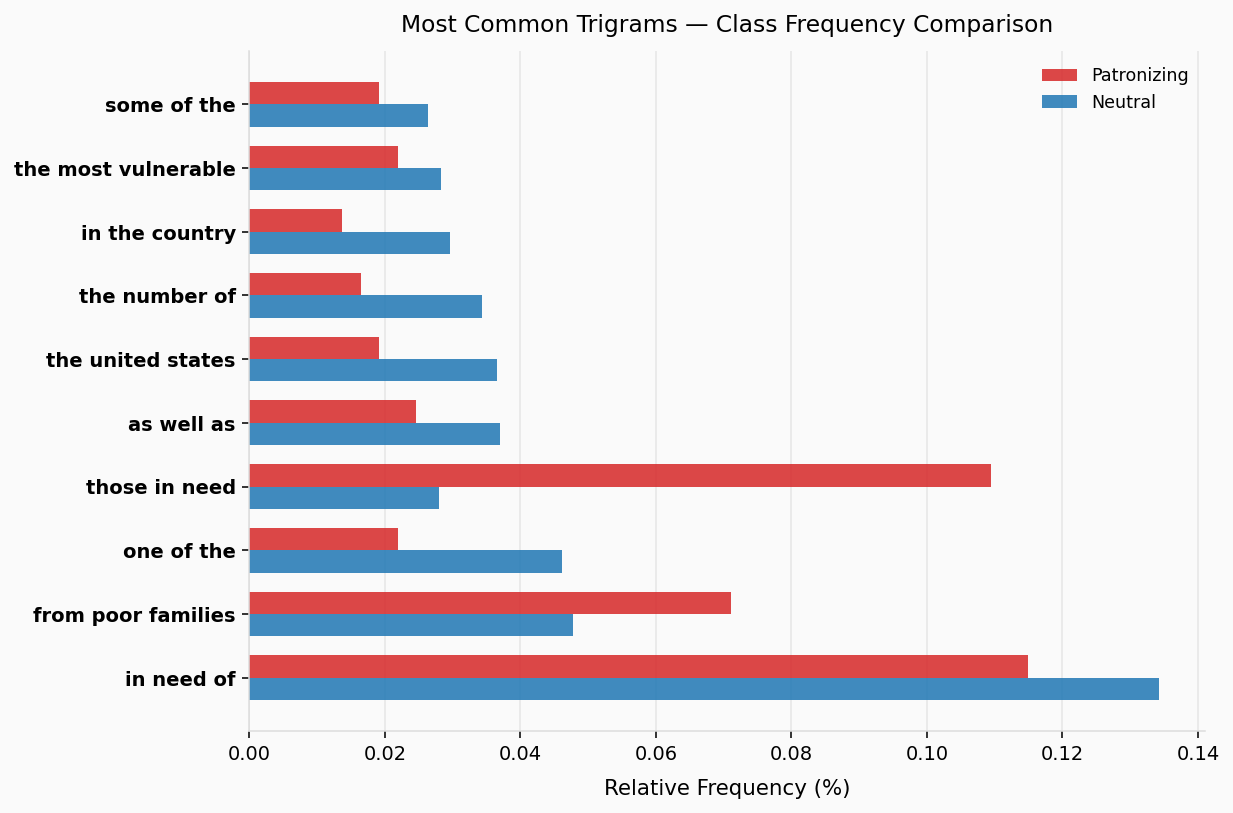

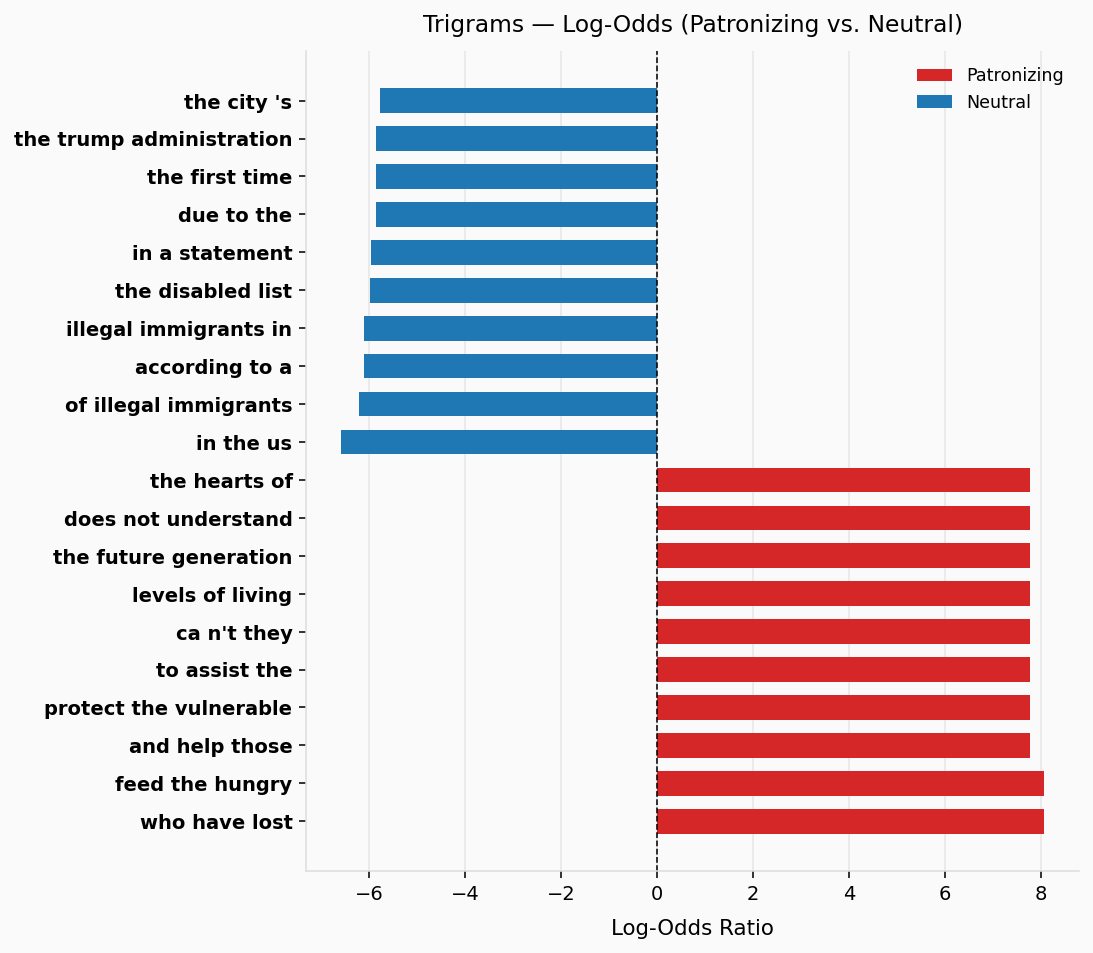


POS — Patronizing
NOUN    : 20.41%
PUNCT   : 13.97%
VERB    : 11.03%
ADP     : 10.79%
ADJ     : 7.63%
DET     : 7.56%
PRON    : 7.12%
AUX     : 4.96%

POS — Neutral
NOUN    : 21.01%
PUNCT   : 13.18%
ADP     : 11.4%
VERB    : 10.72%
ADJ     : 7.99%
DET     : 7.71%
PRON    : 5.63%
AUX     : 5.05%


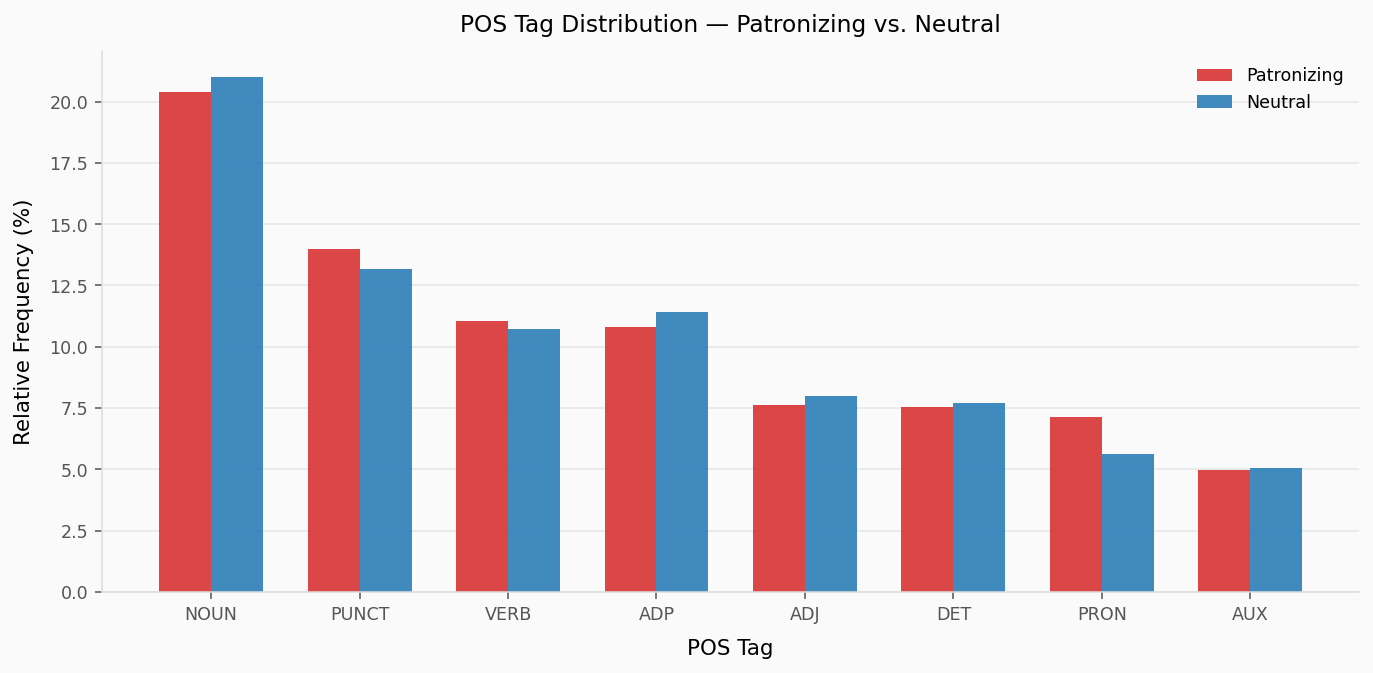

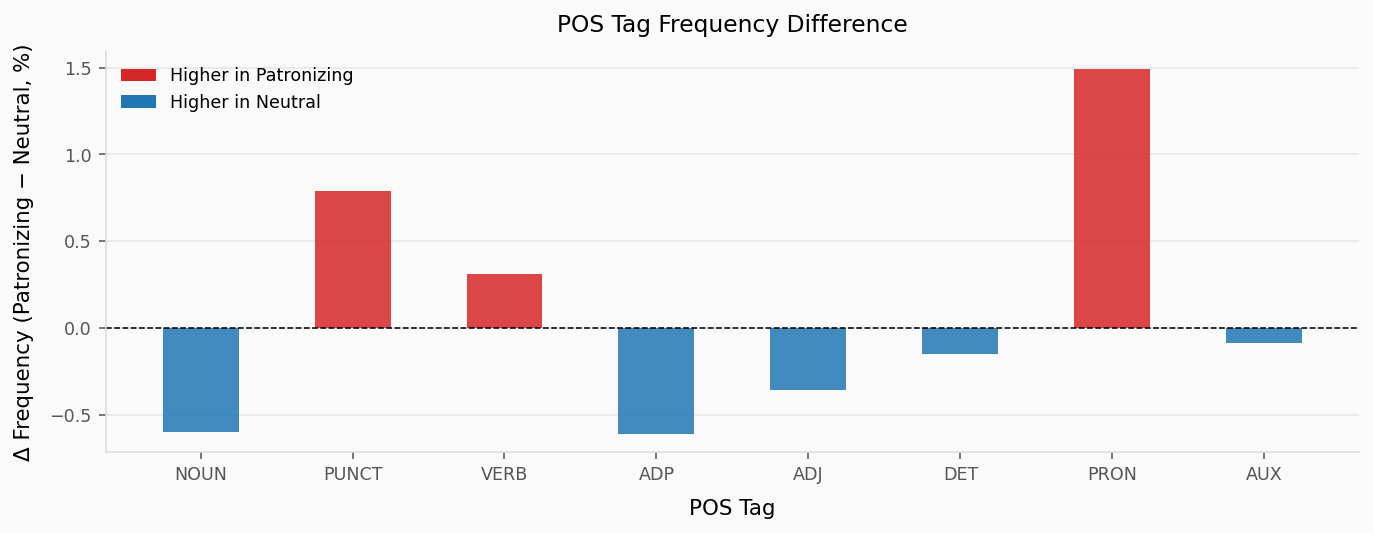


Duplicates remaining : 0
Suggested max_length : 93 tokens

STOPWORDS-REMOVED ANALYSIS

Total samples : 8365
Avg tokens    : 22.9
Min / Max     : 3 / 461
Std tokens    : 13.8
Vocab size    : 27211

Patronizing   : 793 (9.48%)
Neutral       : 7572 (90.52%)
Neutral:Patron: 9.55:1


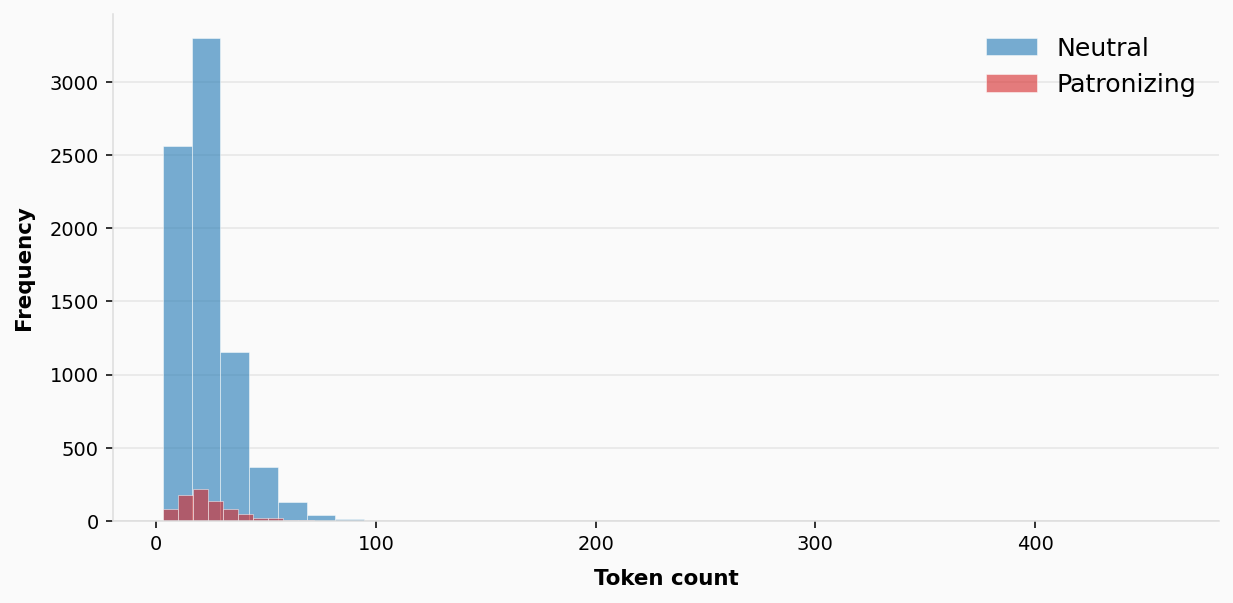

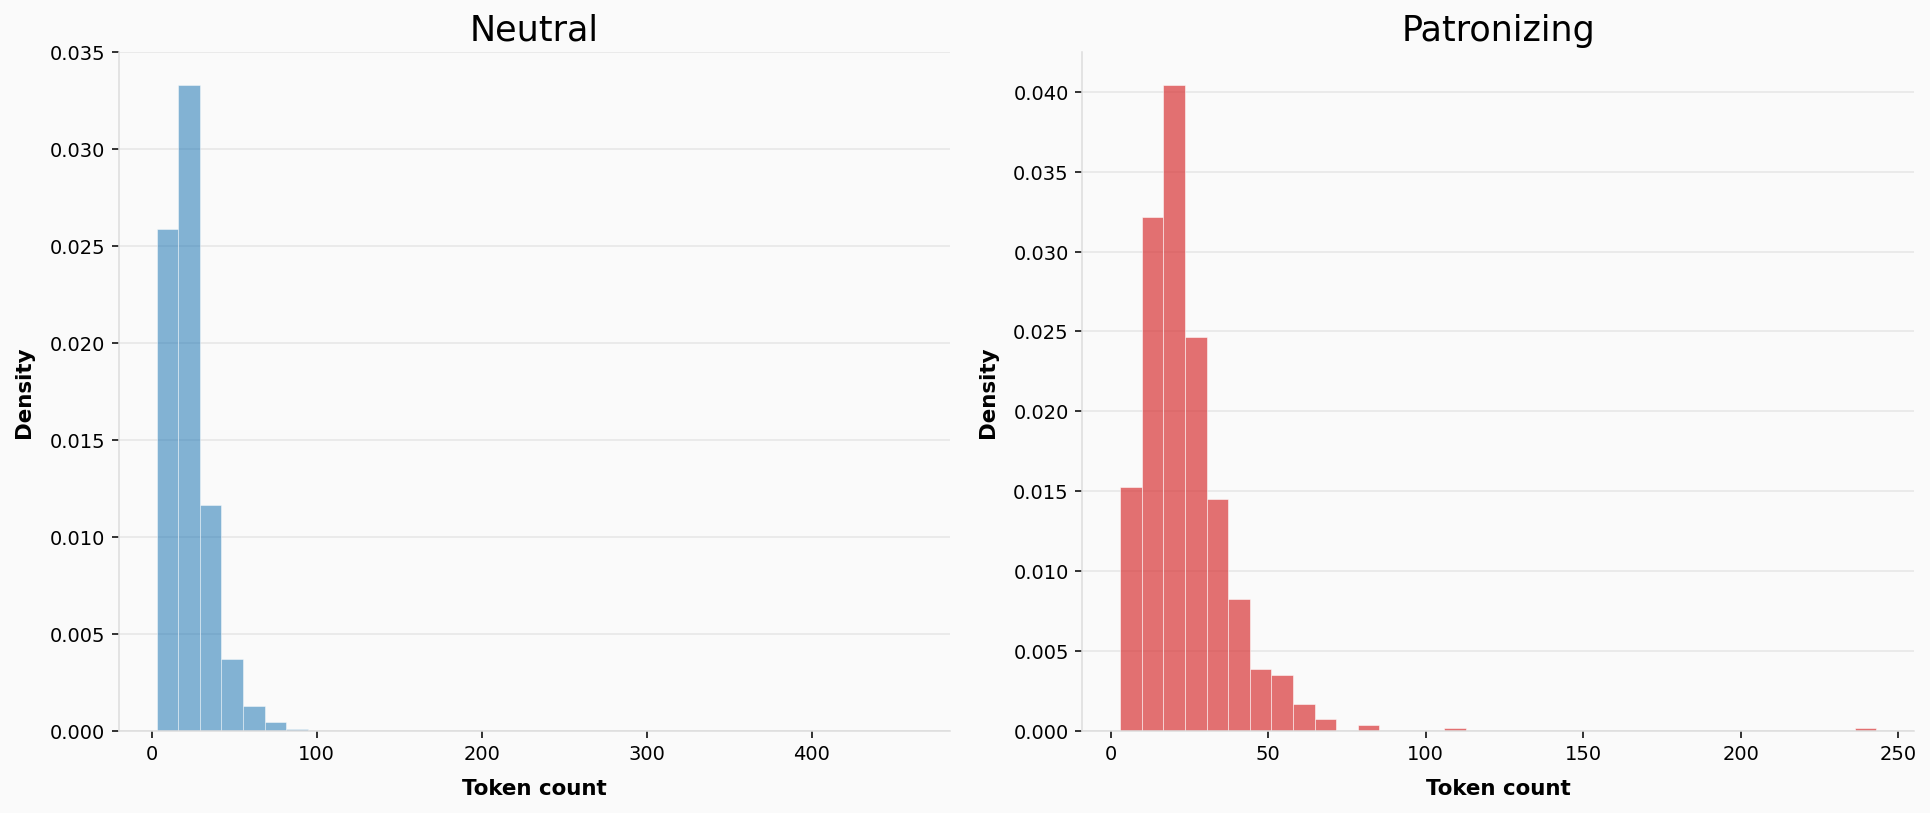

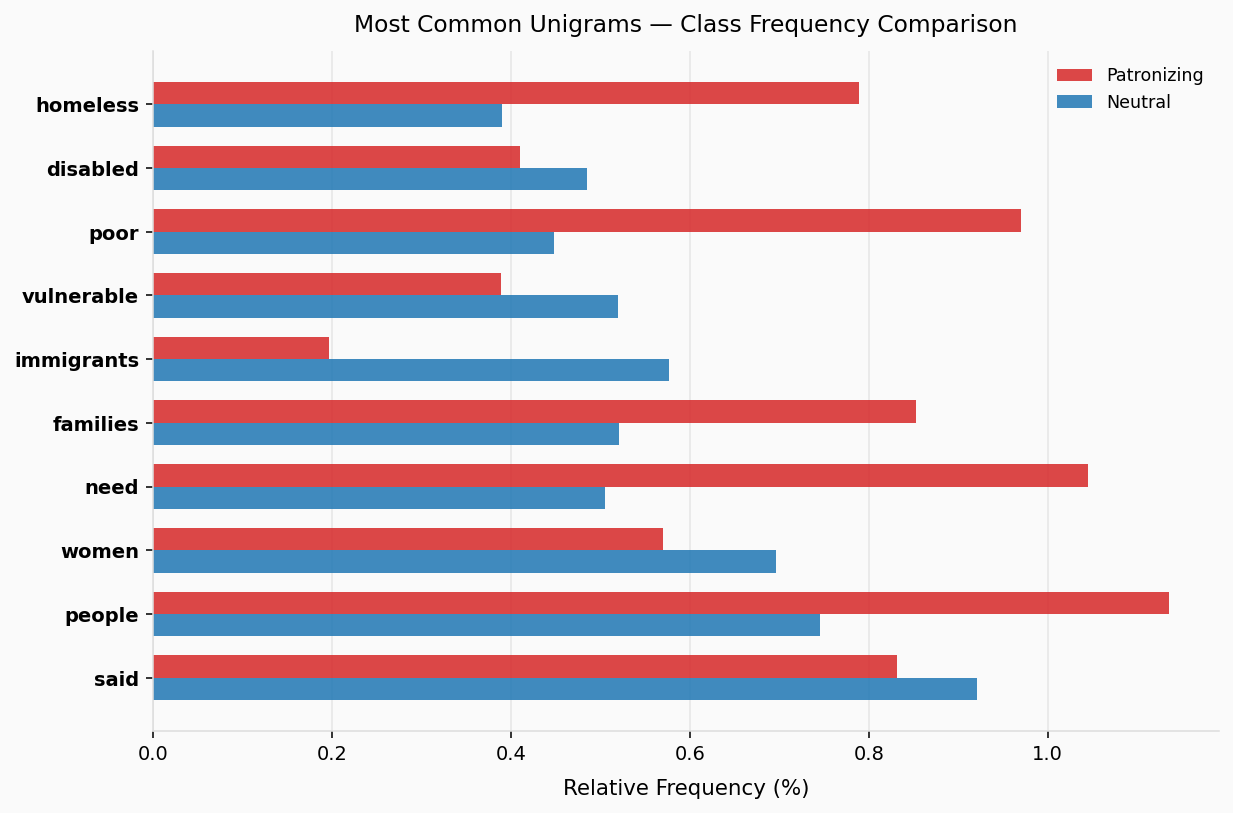

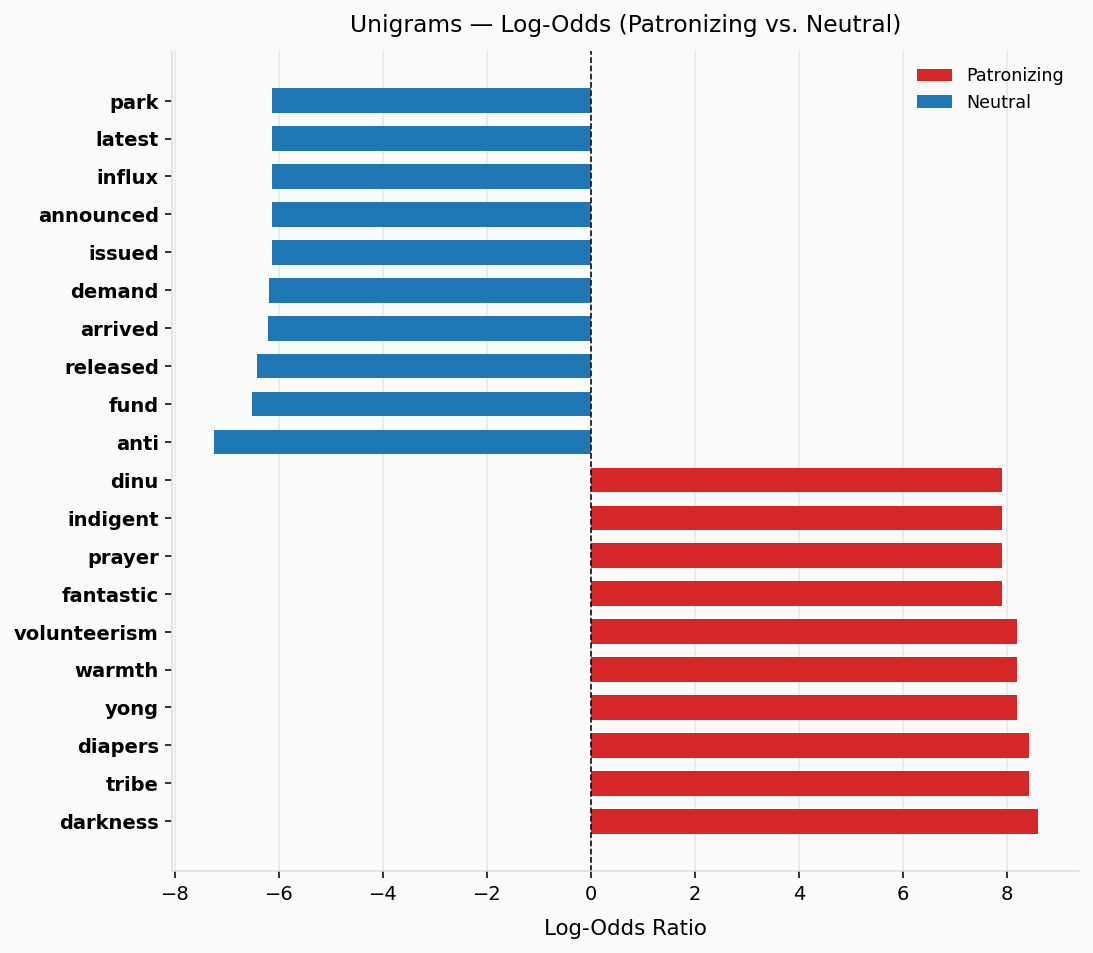

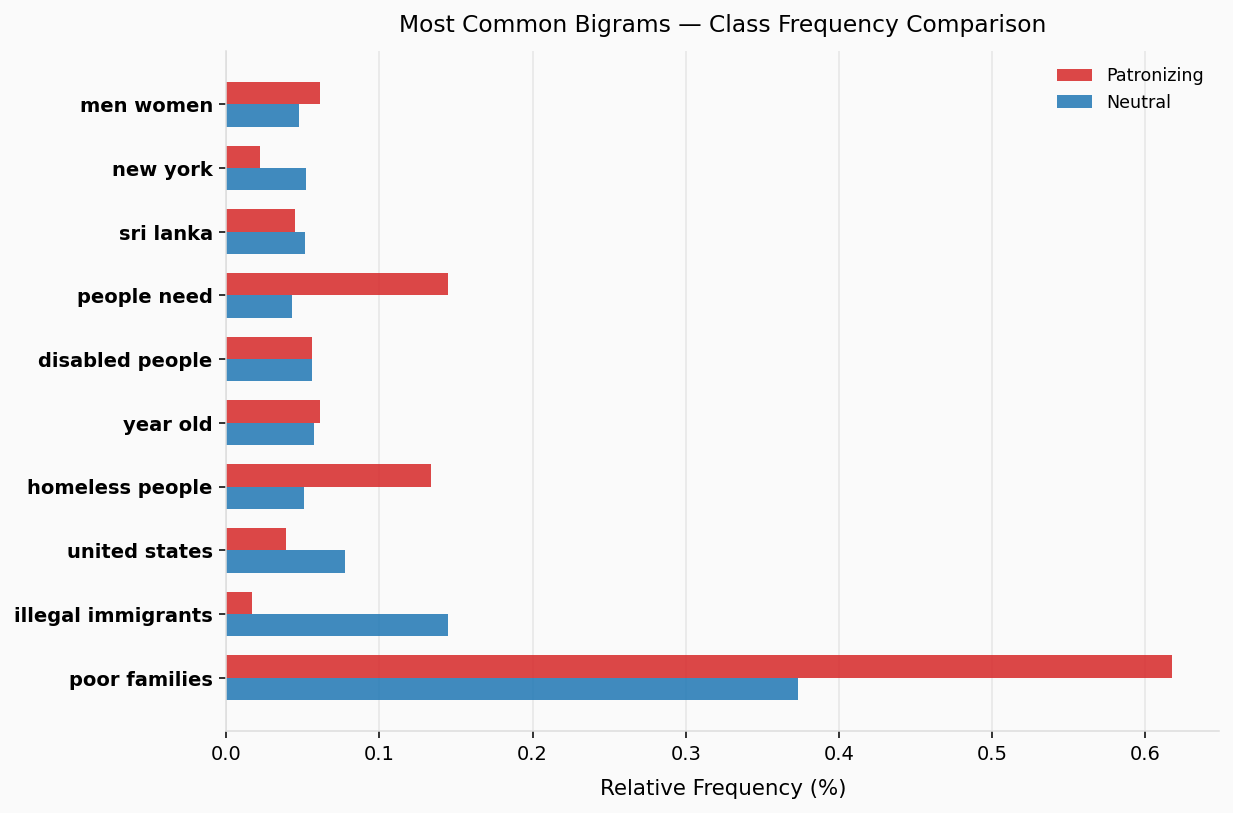

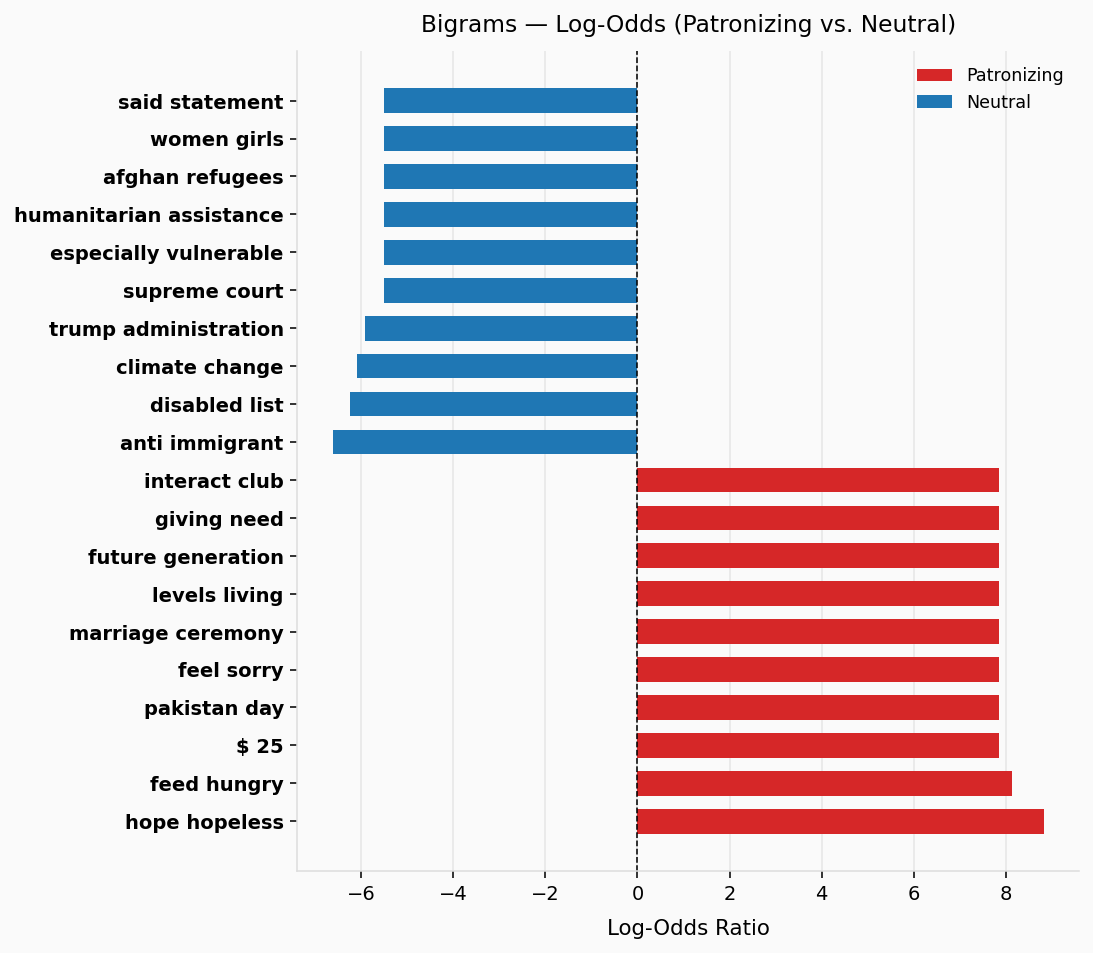

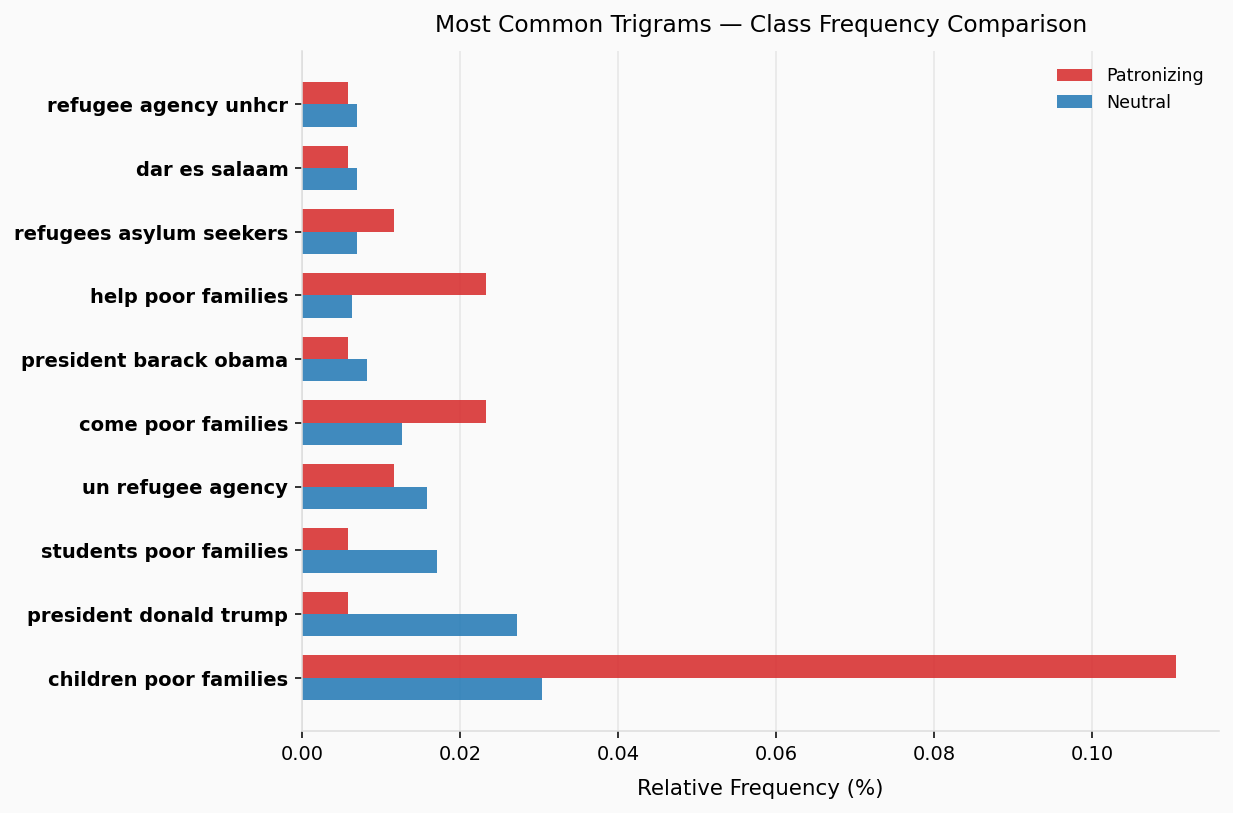

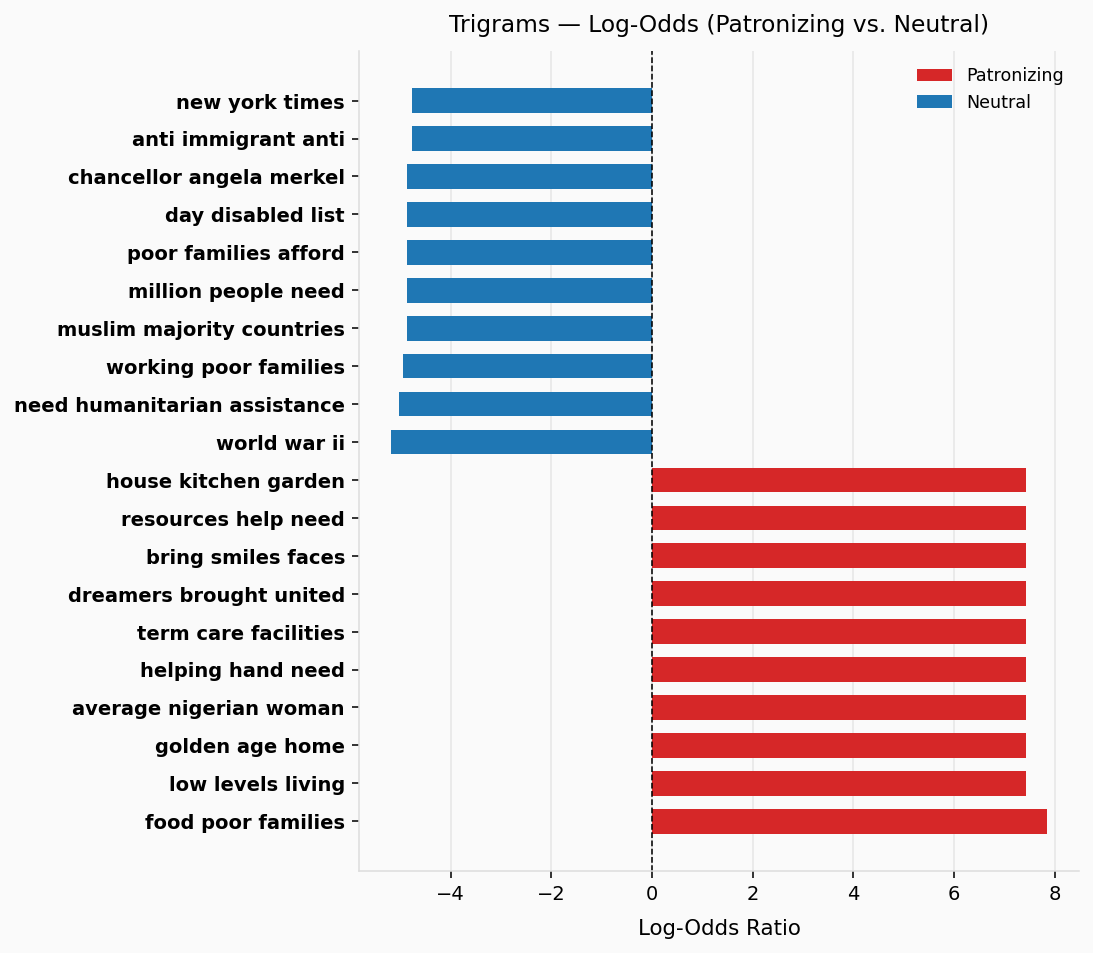


Done.


In [5]:
runFullEda(train_data)